In [1]:
# ============================================================
# INDIAN QUANT PORTFOLIO & RISK ENGINE
# STEP 6: FINAL EVALUATION & NIFTY BENCHMARK
# ============================================================

import os
import numpy as np
import pandas as pd


# ============================================================
# CONFIG
# ============================================================

BACKTEST_DIR = (
    "data/processed/final_backtest"
)

MARKET_FILE = (
    "data/raw/market_prices.csv"
)

OUTPUT_DIR = (
    "data/processed/final_evaluation"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)

TRADING_DAYS = 252


# ============================================================
# LOAD STRATEGY RETURNS
# ============================================================

strategy_returns = pd.read_csv(

    os.path.join(
        BACKTEST_DIR,
        "all_strategy_returns.csv"
    ),

    index_col="Date",

    parse_dates=True
)

strategy_returns = (
    strategy_returns
    .sort_index()
)


# ============================================================
# LOAD NIFTY
# ============================================================

market = pd.read_csv(

    MARKET_FILE,

    index_col="Date",

    parse_dates=True
)

market = market.sort_index()


if "^NSEI" not in market.columns:

    raise ValueError(
        "NIFTY 50 (^NSEI) not found "
        "in market_prices.csv"
    )


nifty_returns = (
    market["^NSEI"]
    .pct_change()
    .rename("NIFTY_50")
)


# ============================================================
# ALIGN BENCHMARK
# ============================================================

evaluation_data = pd.concat(

    [
        strategy_returns,
        nifty_returns
    ],

    axis=1

).dropna()


print("=" * 75)
print("FINAL EVALUATION")
print("=" * 75)

print(
    f"\nEvaluation period:"
)

print(
    f"{evaluation_data.index.min().date()}"
    f" → "
    f"{evaluation_data.index.max().date()}"
)

print(
    f"\nObservations: "
    f"{len(evaluation_data)}"
)


# ============================================================
# PERFORMANCE FUNCTION
# ============================================================

def performance_metrics(
    returns
):

    returns = returns.dropna()

    total_return = (
        1 + returns
    ).prod() - 1

    years = (
        len(returns)
        / TRADING_DAYS
    )

    cagr = (
        (
            1
            + total_return
        )
        ** (1 / years)
        - 1
    )

    volatility = (
        returns.std()
        * np.sqrt(
            TRADING_DAYS
        )
    )

    sharpe = (
        returns.mean()
        * TRADING_DAYS
        / volatility
        if volatility > 0
        else np.nan
    )

    downside = (
        returns
        .clip(upper=0)
        .std()
        * np.sqrt(
            TRADING_DAYS
        )
    )

    sortino = (
        returns.mean()
        * TRADING_DAYS
        / downside
        if downside > 0
        else np.nan
    )

    cumulative = (
        1 + returns
    ).cumprod()

    drawdown = (
        cumulative
        / cumulative.cummax()
    ) - 1

    maximum_drawdown = (
        drawdown.min()
    )

    calmar = (
        cagr
        / abs(
            maximum_drawdown
        )
        if maximum_drawdown < 0
        else np.nan
    )

    var_95 = (
        returns
        .quantile(0.05)
    )

    cvar_95 = (
        returns[
            returns <= var_95
        ]
        .mean()
    )

    return {

        "Total_Return":
            total_return,

        "CAGR":
            cagr,

        "Annualized_Volatility":
            volatility,

        "Sharpe_Ratio":
            sharpe,

        "Sortino_Ratio":
            sortino,

        "Maximum_Drawdown":
            maximum_drawdown,

        "Calmar_Ratio":
            calmar,

        "VaR_95":
            var_95,

        "CVaR_95":
            cvar_95,

        "Positive_Days_%":
            (
                returns > 0
            ).mean(),

        "Observations":
            len(returns)
    }


# ============================================================
# CALCULATE PERFORMANCE
# ============================================================

performance = {}

for column in evaluation_data.columns:

    performance[
        column
    ] = performance_metrics(
        evaluation_data[column]
    )


performance_df = pd.DataFrame(
    performance
).T


# ============================================================
# ALPHA / BETA / TRACKING METRICS
# ============================================================

benchmark = (
    evaluation_data[
        "NIFTY_50"
    ]
)


benchmark_variance = (
    benchmark.var()
)


relative_metrics = {}


for strategy in strategy_returns.columns:

    portfolio = (
        evaluation_data[
            strategy
        ]
    )

    covariance = (
        portfolio
        .cov(
            benchmark
        )
    )

    beta = (
        covariance
        / benchmark_variance
    )

    # CAPM-style daily alpha
    alpha_daily = (
        portfolio.mean()
        - beta
        * benchmark.mean()
    )

    alpha_annualized = (
        alpha_daily
        * TRADING_DAYS
    )

    active_returns = (
        portfolio
        - benchmark
    )

    tracking_error = (
        active_returns.std()
        * np.sqrt(
            TRADING_DAYS
        )
    )

    active_return = (
        active_returns.mean()
        * TRADING_DAYS
    )

    information_ratio = (

        active_return
        / tracking_error

        if tracking_error > 0

        else np.nan
    )

    relative_metrics[
        strategy
    ] = {

        "Beta_to_NIFTY":
            beta,

        "Alpha_Annualized":
            alpha_annualized,

        "Excess_Return_Annualized":
            active_return,

        "Tracking_Error":
            tracking_error,

        "Information_Ratio":
            information_ratio
    }


relative_metrics_df = pd.DataFrame(
    relative_metrics
).T


# ============================================================
# COMBINE RESULTS
# ============================================================

final_comparison = (
    performance_df
    .join(
        relative_metrics_df
    )
)


# ============================================================
# CUMULATIVE PERFORMANCE
# ============================================================

cumulative = (
    1 + evaluation_data
).cumprod()


# ============================================================
# YEARLY RETURNS
# ============================================================

yearly_returns = (
    evaluation_data
    .resample("YE")
    .apply(
        lambda x:
        (1 + x).prod() - 1
    )
)


# ============================================================
# MONTHLY RETURNS
# ============================================================

monthly_returns = (
    evaluation_data
    .resample("ME")
    .apply(
        lambda x:
        (1 + x).prod() - 1
    )
)


# ============================================================
# DRAWDOWN
# ============================================================

drawdown = (
    cumulative
    / cumulative.cummax()
) - 1


# ============================================================
# OUTPERFORMANCE
# ============================================================

nifty_cagr = (
    final_comparison
    .loc[
        "NIFTY_50",
        "CAGR"
    ]
    if "NIFTY_50"
    in final_comparison.index
    else np.nan
)

outperformance = pd.DataFrame(
    index=strategy_returns.columns
)

outperformance[
    "CAGR"
] = final_comparison.loc[
    strategy_returns.columns,
    "CAGR"
]

outperformance[
    "NIFTY_CAGR"
] = nifty_cagr

outperformance[
    "CAGR_Advantage"
] = (
    outperformance[
        "CAGR"
    ]
    - nifty_cagr
)

outperformance[
    "Sharpe_Advantage"
] = (
    final_comparison.loc[
        strategy_returns.columns,
        "Sharpe_Ratio"
    ]
    -
    final_comparison.loc[
        "NIFTY_50",
        "Sharpe_Ratio"
    ]
)


# ============================================================
# RANKING
# ============================================================

ranking = pd.DataFrame(
    index=final_comparison.index
)

ranking[
    "Sharpe_Rank"
] = (
    final_comparison[
        "Sharpe_Ratio"
    ]
    .rank(
        ascending=False
    )
)

ranking[
    "CAGR_Rank"
] = (
    final_comparison[
        "CAGR"
    ]
    .rank(
        ascending=False
    )
)

ranking[
    "Sortino_Rank"
] = (
    final_comparison[
        "Sortino_Ratio"
    ]
    .rank(
        ascending=False
    )
)

ranking[
    "Drawdown_Rank"
] = (
    final_comparison[
        "Maximum_Drawdown"
    ]
    .rank(
        ascending=False
    )
)


# ============================================================
# SAVE
# ============================================================

evaluation_data.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "evaluation_returns.csv"
    )
)

final_comparison.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "final_performance_comparison.csv"
    )
)

cumulative.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "cumulative_performance.csv"
    )
)

drawdown.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "drawdown_comparison.csv"
    )
)

yearly_returns.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "yearly_returns.csv"
    )
)

monthly_returns.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "monthly_returns.csv"
    )
)

outperformance.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "outperformance_vs_nifty.csv"
    )
)

ranking.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "strategy_ranking.csv"
    )
)


# ============================================================
# PRINT RESULTS
# ============================================================

print("\n" + "=" * 75)
print("PERFORMANCE VS NIFTY 50")
print("=" * 75)

columns = [

    "CAGR",

    "Annualized_Volatility",

    "Sharpe_Ratio",

    "Sortino_Ratio",

    "Maximum_Drawdown",

    "Calmar_Ratio",

    "VaR_95",

    "CVaR_95",

    "Beta_to_NIFTY",

    "Alpha_Annualized",

    "Information_Ratio"
]


print(
    final_comparison[
        columns
    ]
    .sort_values(
        "Sharpe_Ratio",
        ascending=False
    )
    .round(4)
)


print("\n" + "=" * 75)
print("OUTPERFORMANCE VS NIFTY")
print("=" * 75)

print(
    outperformance
    .sort_values(
        "CAGR_Advantage",
        ascending=False
    )
    .round(4)
)


print("\n" + "=" * 75)
print("STRATEGY RANKING")
print("=" * 75)

print(
    ranking
    .sort_values(
        "Sharpe_Rank"
    )
)


print("\n" + "=" * 75)
print("FINAL EVALUATION COMPLETE")
print("=" * 75)

print(
    f"\nResults saved to:"
)

print(
    OUTPUT_DIR
)

FINAL EVALUATION

Evaluation period:
2017-01-18 → 2026-07-23

Observations: 2346

PERFORMANCE VS NIFTY 50
                    CAGR  Annualized_Volatility  Sharpe_Ratio  Sortino_Ratio  \
XGBoost           0.3998                 0.1628        2.1490         3.6658   
Random_Forest     0.3431                 0.1612        1.9120         3.2414   
Equal_Weight      0.1804                 0.1547        1.1502         1.8227   
Minimum_Variance  0.1621                 0.1395        1.1470         1.8541   
Maximum_Sharpe    0.1778                 0.1596        1.1056         1.7813   
Risk_Parity       0.1751                 0.1967        0.9192         1.4656   
NIFTY_50          0.1187                 0.1637        0.7680         1.1750   

                  Maximum_Drawdown  Calmar_Ratio  VaR_95  CVaR_95  \
XGBoost                    -0.2198        1.8191 -0.0143  -0.0219   
Random_Forest              -0.2383        1.4399 -0.0143  -0.0221   
Equal_Weight               -0.3238        0.55

/var/folders/z8/txw1dwts4zs619_720bsj9ww0000gn/T/ipykernel_8644/2872746756.py:92: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  evaluation_data = pd.concat(


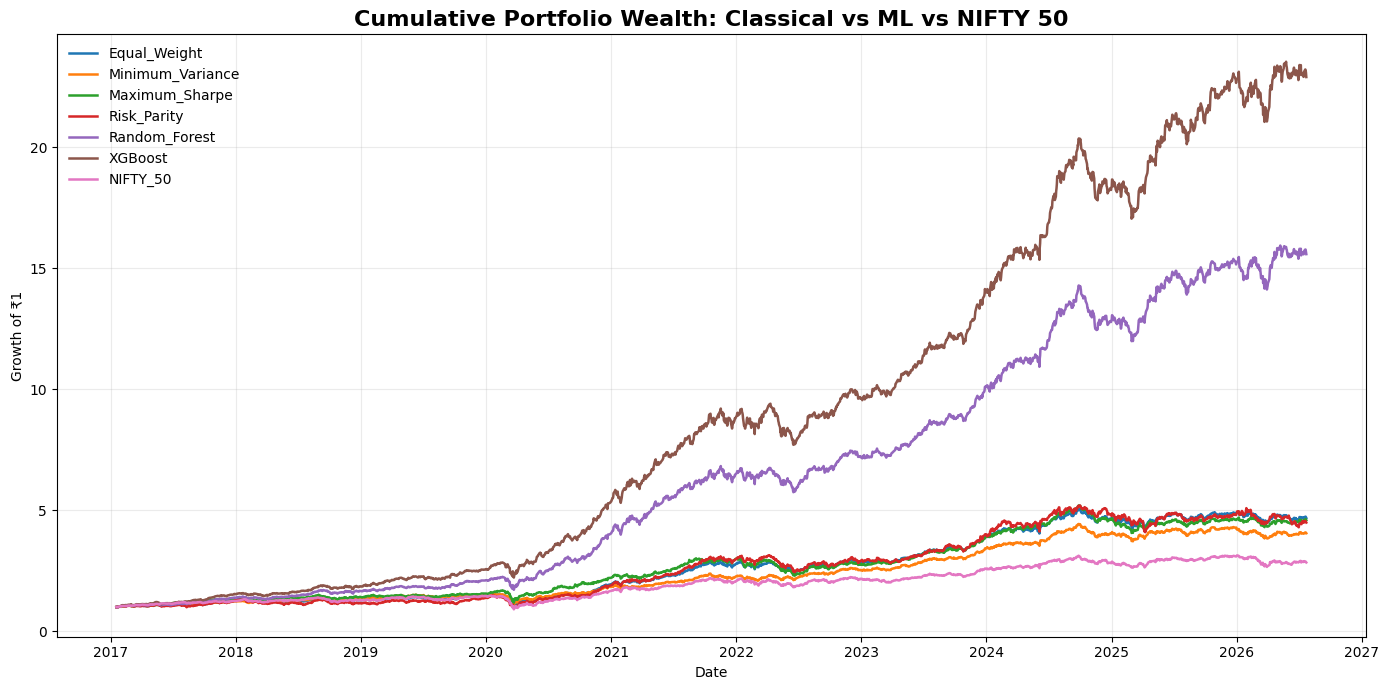

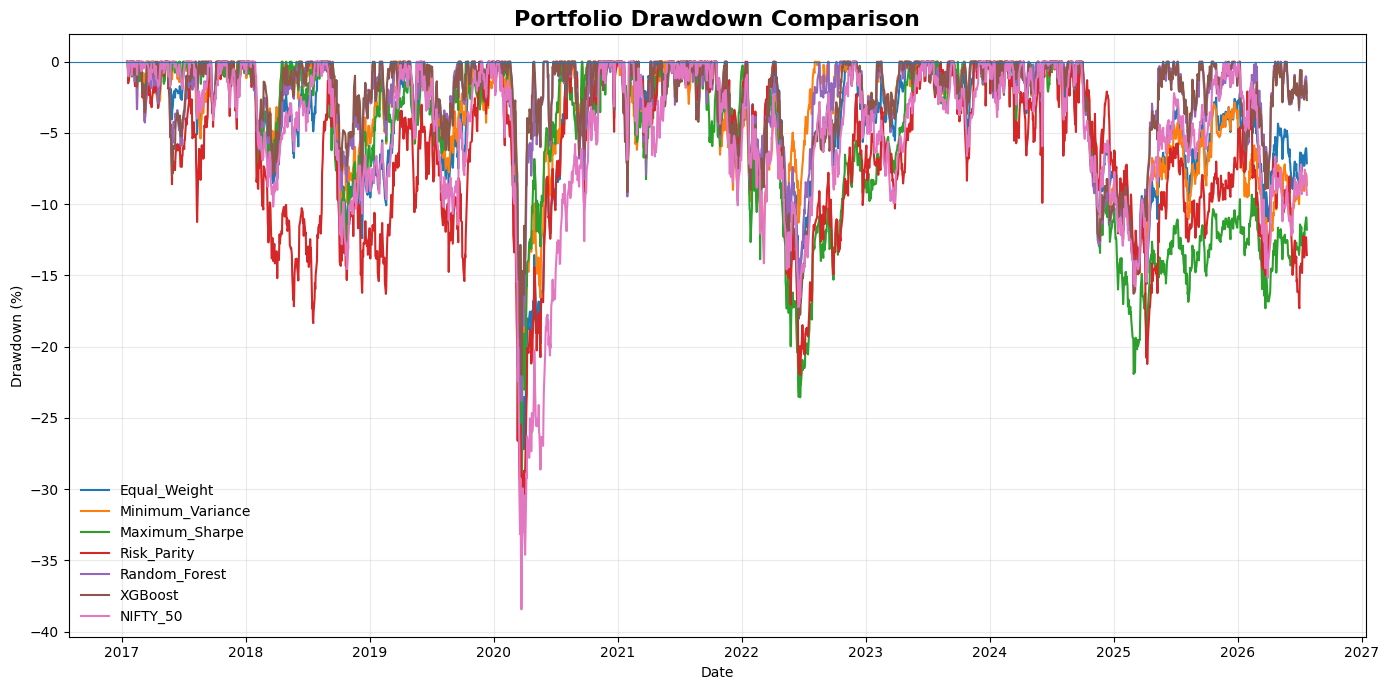

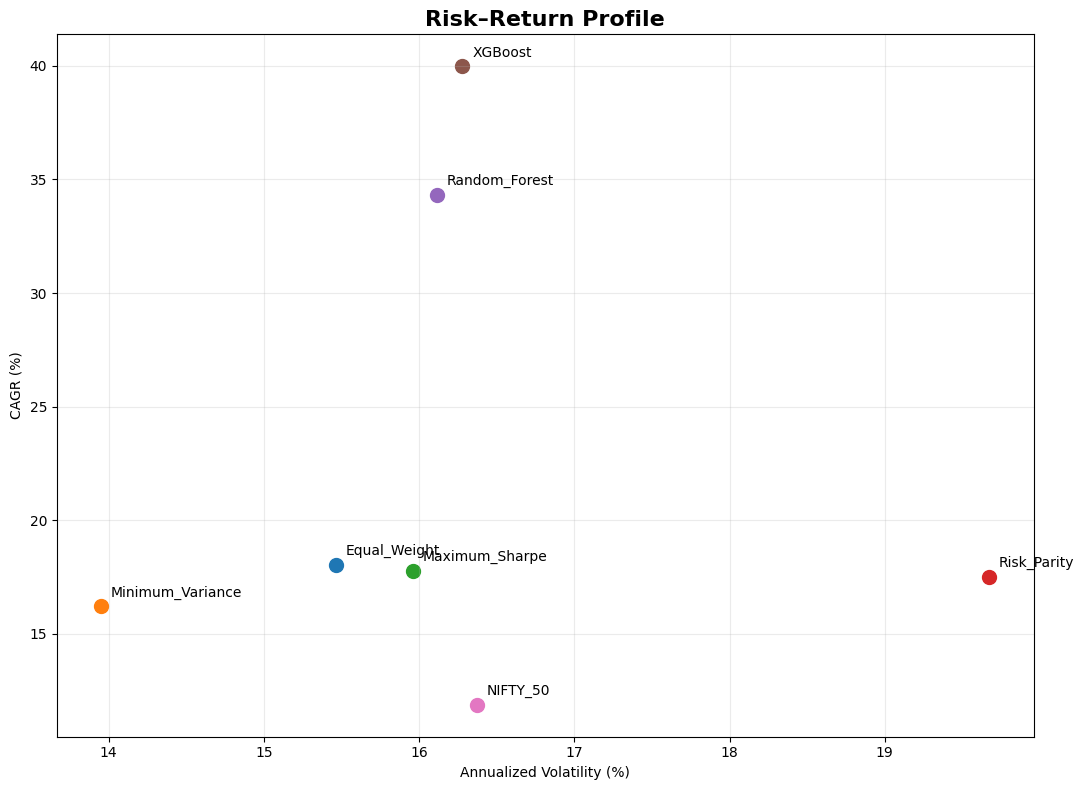

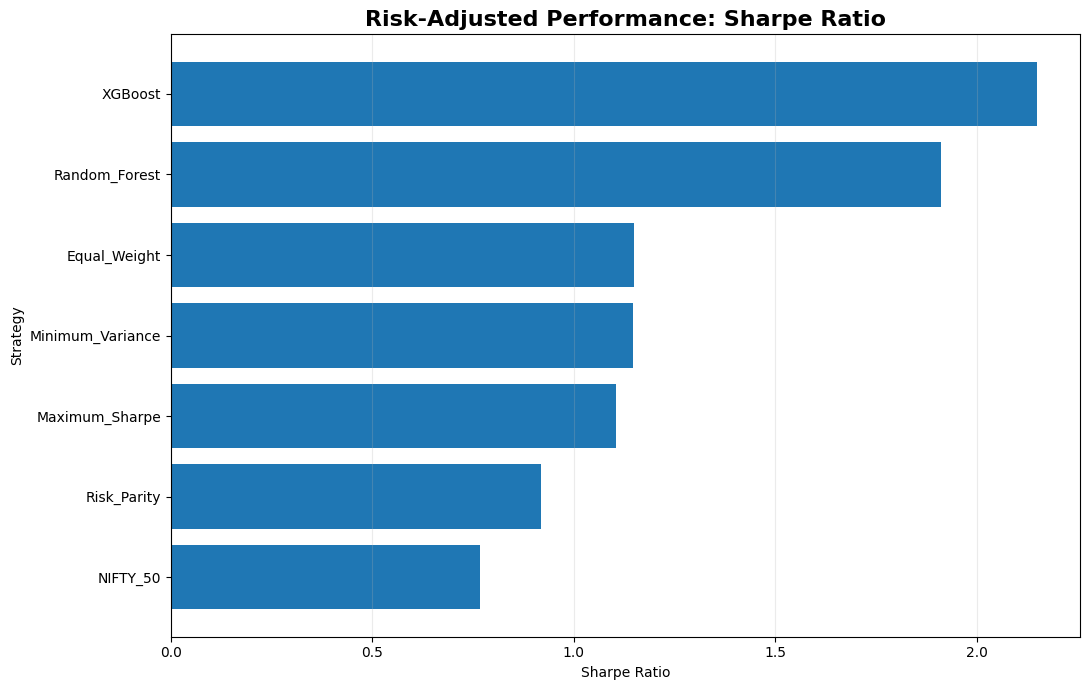


GRAPHS CREATED


In [5]:
import matplotlib.pyplot as plt

# ============================================================
# GRAPH 1
# CUMULATIVE PERFORMANCE
# ============================================================

plt.figure(figsize=(14, 7))

for column in cumulative.columns:

    plt.plot(
        cumulative.index,
        cumulative[column],
        label=column,
        linewidth=1.8
    )

plt.title(
    "Cumulative Portfolio Wealth: Classical vs ML vs NIFTY 50",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Growth of ₹1"
)

plt.legend(
    loc="upper left",
    frameon=False
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# GRAPH 2
# DRAWDOWN
# ============================================================

plt.figure(figsize=(14, 7))

for column in drawdown.columns:

    plt.plot(
        drawdown.index,
        drawdown[column] * 100,
        label=column,
        linewidth=1.5
    )

plt.title(
    "Portfolio Drawdown Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Drawdown (%)"
)

plt.axhline(
    0,
    linewidth=0.8
)

plt.legend(
    loc="lower left",
    frameon=False
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()


# ============================================================
# GRAPH 3
# RISK-RETURN
# ============================================================

plt.figure(figsize=(11, 8))

for strategy in final_comparison.index:

    x = (
        final_comparison.loc[
            strategy,
            "Annualized_Volatility"
        ]
        * 100
    )

    y = (
        final_comparison.loc[
            strategy,
            "CAGR"
        ]
        * 100
    )

    plt.scatter(
        x,
        y,
        s=100
    )

    plt.annotate(
        strategy,
        (
            x,
            y
        ),
        xytext=(
            7,
            7
        ),
        textcoords="offset points"
    )


plt.title(
    "Risk–Return Profile",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Annualized Volatility (%)"
)

plt.ylabel(
    "CAGR (%)"
)

plt.grid(
    alpha=0.25
)

plt.tight_layout()


plt.show()


# ============================================================
# GRAPH 4
# SHARPE RATIO
# ============================================================

sharpe = (
    final_comparison[
        "Sharpe_Ratio"
    ]
    .sort_values(
        ascending=True
    )
)

plt.figure(figsize=(11, 7))

plt.barh(
    sharpe.index,
    sharpe.values
)

plt.title(
    "Risk-Adjusted Performance: Sharpe Ratio",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Sharpe Ratio"
)

plt.ylabel(
    "Strategy"
)

plt.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()


plt.show()


# ============================================================
# SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("GRAPHS CREATED")
print("=" * 70)